In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import glob

from statsmodels.robust import mad
from scipy.stats import pearsonr

from muldoon.read_data import *
from muldoon.utils import *
from local_utils import *

In [11]:
# Read in vortices
vortex_data = culled_vortices("../data/data_derived_env/fit_all_vortices.csv")

# Read in data file - We just have the one for now.
desired_sol = 30
time, RDS_data = get_RDS_data(desired_sol)

/Users/bjackson/research/Active Projects/Vortices-and-Dust-Devils-As-Observed-by-Mars-2020/code/local_utils.py:287: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  RDS_data = np.genfromtxt(filename, delimiter=',',


('SCLK', 'LMST', 'LTST', 'RDS_LAT_1', 'RDS_LAT_2', 'RDS_LAT_3', 'RDS_LAT_4', 'RDS_LAT_5', 'RDS_LAT_6', 'RDS_LAT_7', 'RDS_LAT_8', 'RDS_TOP_1', 'RDS_TOP_2', 'RDS_TOP_3', 'RDS_TOP_4', 'RDS_TOP_5', 'RDS_TOP_6', 'RDS_TOP_7', 'RDS_TOP_8', 'RDS_LAT_1_HG', 'RDS_LAT_2_HG', 'RDS_LAT_3_HG', 'RDS_LAT_4_HG', 'RDS_LAT_5_HG', 'RDS_LAT_6_HG', 'RDS_LAT_7_HG', 'RDS_LAT_8_HG', 'RDS_TOP_1_HG', 'RDS_TOP_2_HG', 'RDS_TOP_3_HG', 'RDS_TOP_4_HG', 'RDS_TOP_5_HG', 'RDS_TOP_6_HG', 'RDS_TOP_7_HG', 'RDS_TOP_8_HG', 'ROVER_HGA_STILL', 'ROVER_STILL')


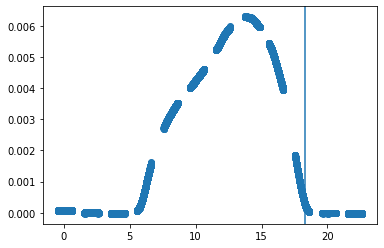

In [57]:
print(RDS_data.dtype.names)
plt.scatter(time, RDS_data['RDS_LAT_7'])

ind = vortex_data['sol'] == desired_sol
for i in range(len(vortex_data['sol'][ind])):
    plt.axvline(vortex_data['t0'][ind][i])

/Users/bjackson/research/Active Projects/Vortices-and-Dust-Devils-As-Observed-by-Mars-2020/code/local_utils.py:287: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  RDS_data = np.genfromtxt(filename, delimiter=',',
/Users/bjackson/research/Active Projects/Vortices-and-Dust-Devils-As-Observed-by-Mars-2020/code/local_utils.py:287: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  RDS_data = np.genfromtxt(filename, delimiter=',',


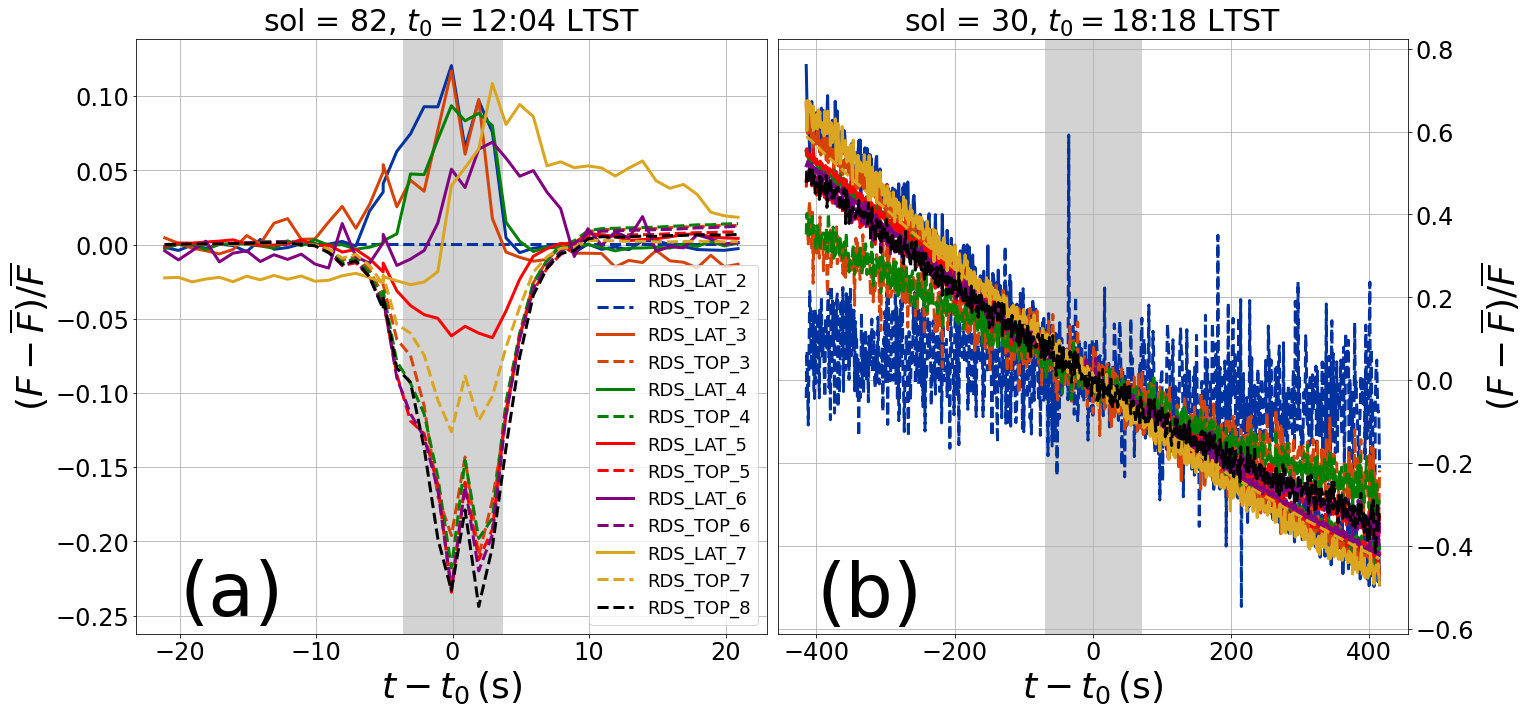

In [2]:
# Plot showing good correlation between RDS and vortex and bad correlation
import itertools

fig = plt.figure(figsize=(12*aspect_ratio, 10))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

line_colors = itertools.cycle((BoiseState_blue, BoiseState_orange, 'green', 'red', 'purple', 'goldenrod'))

# Read in vortices
vortex_data = culled_vortices("../data/data_derived_env/fit_all_vortices.csv")

### Good correlation for sol 82's biggest vortex ###

# Read in data file - We just have the one for now.
desired_sol = 82
time, RDS_data = get_RDS_data(desired_sol)
ind = vortex_data['sol'] == desired_sol
oind = np.abs(time - vortex_data['t0'][ind][0]) < 3.*vortex_data['Gamma'][ind][0]/3600.

# Make sensors that are co-located plot together
for sensor_number in range(2, 8):

    cur_line_color = next(line_colors)
    
    lat_sensor_name = "RDS_LAT_%i" % sensor_number
    top_sensor_name = "RDS_TOP_%i" % sensor_number
    ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
               (RDS_data[lat_sensor_name][oind] -\
                np.nanmedian(RDS_data[lat_sensor_name][oind]))/np.nanmedian(RDS_data[lat_sensor_name][oind]), 
            lw=3, color=cur_line_color, label=lat_sensor_name)
    
    ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
           (RDS_data[top_sensor_name][oind] -\
            np.nanmedian(RDS_data[top_sensor_name][oind]))/np.nanmedian(RDS_data[top_sensor_name][oind]), 
        lw=3, ls='--', color=cur_line_color, label=top_sensor_name)
    
# And then the last sensor
ax.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
       (RDS_data['RDS_TOP_8'][oind] -\
        np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]), 
    lw=3, ls='--', color='black', label='RDS_TOP_8')

# # The maximum departure
# print(np.max(np.abs((RDS_data['RDS_TOP_8'][oind] -\
#         np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]))))

ax.axvspan(-0.5*vortex_data['Gamma'][ind][0], 0.5*vortex_data['Gamma'][ind][0], color='lightgrey', zorder=-1)
ax.legend(fontsize=18, loc='lower right')
ax.tick_params(labelsize=24)
ax.set_xlabel(r'$t - t_0\,\left( {\rm s} \right)$', fontsize=36)
ax.set_ylabel(r'$\left( F - \overline{F} \right)/\overline{F}$', fontsize=36)

# Format LTST
hour = int(np.floor(vortex_data['t0'][ind][0]))
mn = np.floor((vortex_data['t0'][ind][0] - hour)*60)
ax.set_title(r'sol = %s, $t_0 = $%i:%02i LTST' %\
        (desired_sol, hour, mn), fontsize=30)
ax.text(-20, -0.25, "(a)", fontsize=75)
ax.grid(True)

### Bad correlation for sol 30's biggest vortex

desired_sol = 30
time, RDS_data = get_RDS_data(desired_sol)
ind = vortex_data['sol'] == desired_sol
oind = np.abs(time - vortex_data['t0'][ind][0]) < 3.*vortex_data['Gamma'][ind][0]/3600.

# Make sensors that are co-located plot together
for sensor_number in range(2, 8):

    cur_line_color = next(line_colors)
    
    lat_sensor_name = "RDS_LAT_%i" % sensor_number
    top_sensor_name = "RDS_TOP_%i" % sensor_number
    ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
               (RDS_data[lat_sensor_name][oind] -\
                np.nanmedian(RDS_data[lat_sensor_name][oind]))/np.nanmedian(RDS_data[lat_sensor_name][oind]), 
            lw=3, color=cur_line_color, label=lat_sensor_name)
    
    ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
           (RDS_data[top_sensor_name][oind] -\
            np.nanmedian(RDS_data[top_sensor_name][oind]))/np.nanmedian(RDS_data[top_sensor_name][oind]), 
        lw=3, ls='--', color=cur_line_color, label=top_sensor_name)
    
# And then the last sensor
ax2.plot((time[oind] - vortex_data['t0'][ind][0])*3600., 
       (RDS_data['RDS_TOP_8'][oind] -\
        np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]), 
    lw=3, ls='--', color='black', label='RDS_TOP_8')

# # The maximum departure
# print(np.max(np.abs((RDS_data['RDS_TOP_8'][oind] -\
#         np.nanmedian(RDS_data['RDS_TOP_8'][oind]))/np.nanmedian(RDS_data['RDS_TOP_8'][oind]))))

ax2.axvspan(-0.5*vortex_data['Gamma'][ind][0], 0.5*vortex_data['Gamma'][ind][0], color='lightgrey', zorder=-1)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.tick_params(labelsize=24, labelright=True)
ax2.set_xlabel(r'$t - t_0\,\left( {\rm s} \right)$', fontsize=36)
ax2.set_ylabel(r'$\left( F - \overline{F} \right)/\overline{F}$', fontsize=36)

# Format LTST
hour = int(np.floor(vortex_data['t0'][ind][0]))
mn = np.floor((vortex_data['t0'][ind][0] - hour)*60)
ax2.set_title(r'sol = %s, $t_0 = $%i:%02i LTST' %\
        (desired_sol, hour, mn), fontsize=30)
ax2.text(-400, -0.57, "(b)", fontsize=75)
ax2.grid(True)

fig.tight_layout()
# fig.savefig("../figures/vortex_RDS_example.jpg", dpi=300, bbox_inches="tight")

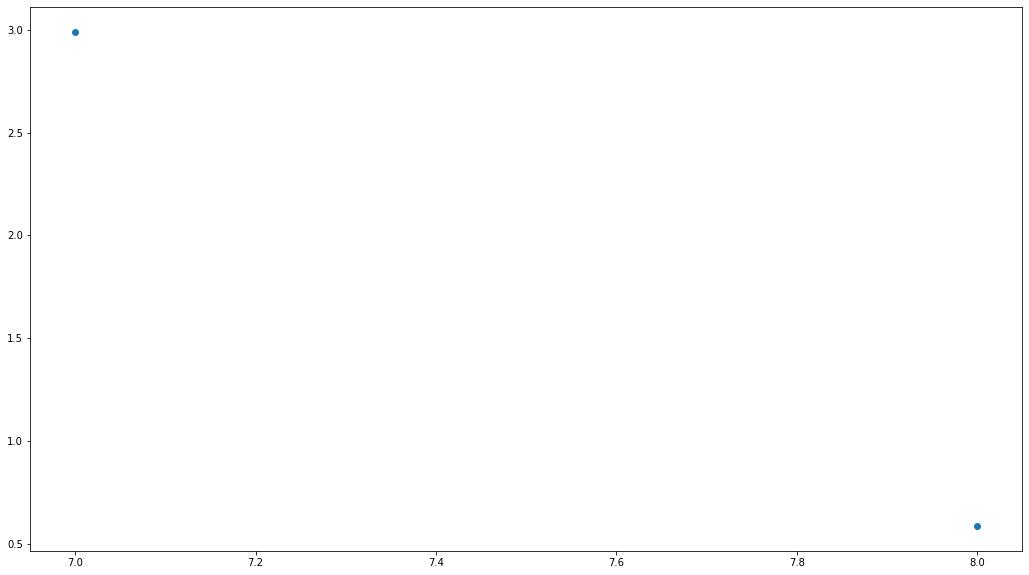

In [5]:
# Estimate the degree of scatter
fig = plt.figure(figsize=(10*aspect_ratio, 10))
ax = fig.add_subplot(111)

during_ind, before_and_after_ind = collect_RDS_points(time, vortex_data['t0'][ind][0],
                                                      vortex_data['Gamma'][ind][0])
list_of_names = ['RDS_LAT_2', 'RDS_LAT_3', 'RDS_LAT_4', 'RDS_LAT_5', 'RDS_LAT_6', 'RDS_LAT_7', 
                 'RDS_LAT_8', 'RDS_TOP_1', 'RDS_TOP_2', 'RDS_TOP_3', 'RDS_TOP_4', 'RDS_TOP_5', 'RDS_TOP_6', 
                 'RDS_TOP_7', 'RDS_TOP_8']

if((len(time[during_ind] > 3)) & ((len(time[before_and_after_ind] > 6)))):

    deltas = np.array([])
    for name in list_of_names:
        in_vortex = RDS_data[name][during_ind]

        out_of_vortex = RDS_data[name][before_and_after_ind]
        med = np.nanmedian(out_of_vortex)
        md = mad(out_of_vortex)

        mx_ind = np.argmax(np.abs(in_vortex - med)/med)

        # Make sure the value is statistically meaningful
        if((in_vortex[mx_ind] - med)/md > 3):
            deltas = np.append(deltas, ((in_vortex - med)/med)[mx_ind])
        else:
            deltas = np.append(deltas, np.nan)

    ax.plot(deltas, marker='o', ls='')

/Users/bjackson/opt/anaconda3/envs/Vortices-and-Dust-Devils-As-Observed-by-Mars-2020/lib/python3.9/site-packages/matplotlib/axes/_base.py:2283: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


(0.054081833037826585, 0.4194935844811949)
0.479192 0.011893
3.1355 0.219155
0.0016906488334523199 4.877761298882753e-06
0.386464


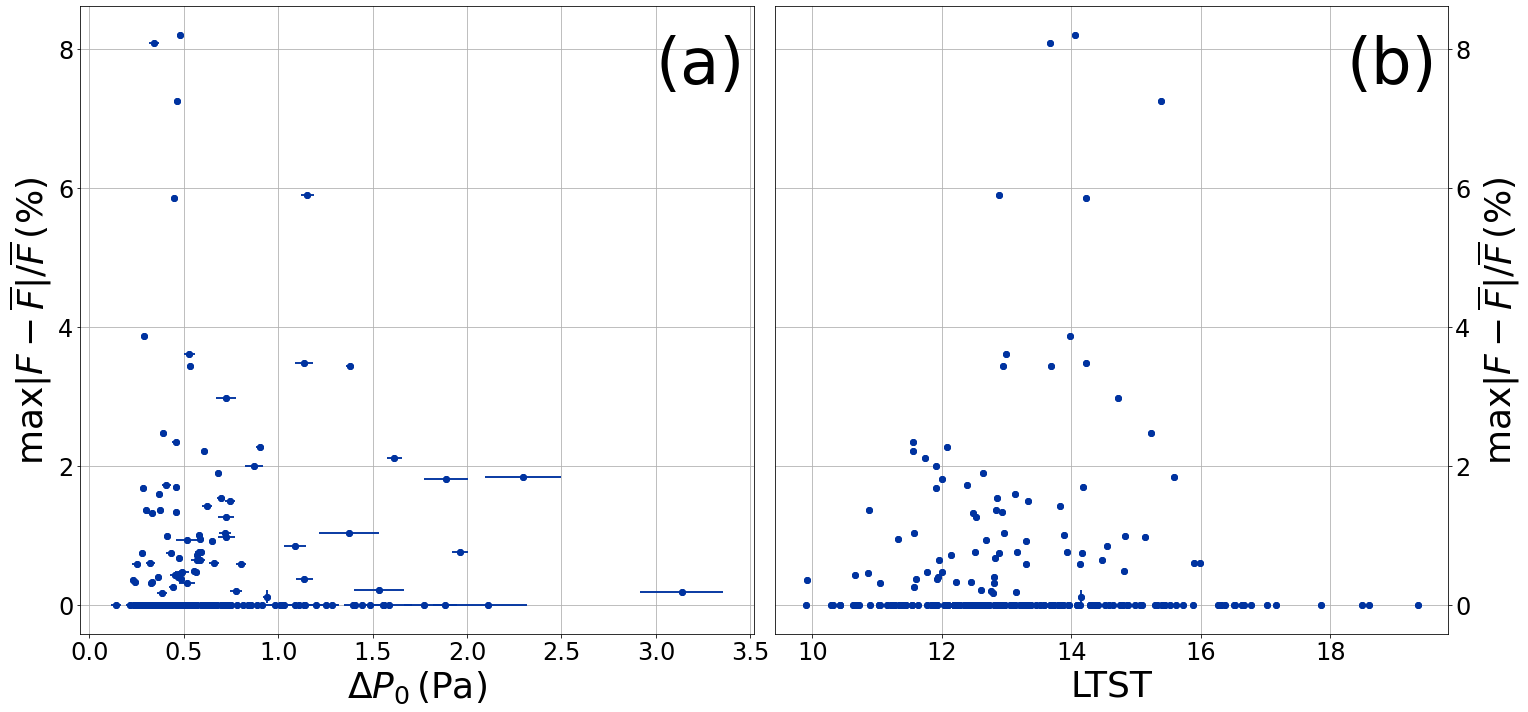

In [14]:
# All the sols
fig = plt.figure(figsize=(12*aspect_ratio, 10))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122, sharey=ax)

# Make list of unique sols
uniq_sols = np.unique(vortex_data['sol'])

# All RDS sensors
list_of_sensors = ['RDS_LAT_2', 'RDS_LAT_3', 'RDS_LAT_4', 'RDS_LAT_5', 'RDS_LAT_6', 'RDS_LAT_7', 
                   'RDS_LAT_8', 'RDS_TOP_1', 'RDS_TOP_2', 'RDS_TOP_3', 'RDS_TOP_4', 'RDS_TOP_5', 'RDS_TOP_6', 
                   'RDS_TOP_7', 'RDS_TOP_8']

# max_RDS_excursion = np.array([])
# max_RDS_excursion_unc = np.array([])
# # Record all the vortices for which we find a meaningful RDS excursion
# saved_vortices = []
# for cur_sol in uniq_sols:
#     print(int(cur_sol))
#     # Collect all vortices from that sol
#     all_vortices_for_cur_sol = vortex_data['sol'] == cur_sol
    
#     # Read in data file - We just have the one for now.
#     time, RDS_data = get_RDS_data(int(cur_sol))
    
#     for i in range(len(vortex_data['t0'][all_vortices_for_cur_sol])):
#         during_ind, before_and_after_ind = collect_RDS_points(time, vortex_data['t0'][all_vortices_for_cur_sol][i],
#                                                               vortex_data['Gamma'][all_vortices_for_cur_sol][i])
    
#         if((len(time[during_ind] > 3)) & ((len(time[before_and_after_ind] > 6)))):

#             deltas = np.array([])
#             mds = np.array([])
#             for name in list_of_sensors:
#                 in_vortex = RDS_data[name][during_ind]

#                 out_of_vortex = RDS_data[name][before_and_after_ind]
#                 med = np.nanmedian(out_of_vortex)
#                 md = mad(out_of_vortex)
                
#                 # Save for uncertainty
#                 mds = np.append(mds, md)

#                 mx_ind = np.argmax(np.abs(in_vortex - med)/med)

#                 # Make sure the value is statistically meaningful
#                 if((in_vortex[mx_ind] - med)/md > 3):
#                     deltas = np.append(deltas, ((in_vortex - med)/med)[mx_ind])
#                 else:
#                     deltas = np.append(deltas, 0.)

#             if(len(deltas) > 0):
#                 saved_vortices.append(vortex_data[:][all_vortices_for_cur_sol][i])
                
#                 mx_ind = np.argmax(deltas)
                
#                 max_RDS_excursion = np.append(max_RDS_excursion, deltas[mx_ind])
#                 max_RDS_excursion_unc = np.append(max_RDS_excursion_unc, mds[mx_ind])

# Some of the values are obviously nonsense. Let's toss the big outliers.

ind = max_RDS_excursion > 0
med = np.nanmedian(max_RDS_excursion[ind])
md = mad(max_RDS_excursion[ind])
num_sigma = 5.

# print(len(max_RDS_excursion[ind]))

saved_max_RDS_excursion = np.array([])
saved_max_RDS_excursion_unc = np.array([])
saved_DeltaP = np.array([])
saved_DeltaP_unc = np.array([])
saved_t0 = np.array([])
saved_t0_unc = np.array([])
for i in range(len(saved_vortices)):
    if((np.abs(max_RDS_excursion[i] - med)/md < num_sigma)):
        ax.errorbar([saved_vortices[i]['DeltaP'], saved_vortices[i]['DeltaP']], 
                    [max_RDS_excursion[i]*100., max_RDS_excursion[i]*100.], marker='o',
                    yerr=[max_RDS_excursion_unc[i], max_RDS_excursion_unc[i]], 
                    xerr=[saved_vortices[i]['DeltaP_unc'], saved_vortices[i]['DeltaP_unc']], 
                    color=BoiseState_blue)

        ax2.errorbar([saved_vortices[i]['t0'], saved_vortices[i]['t0']], 
            [max_RDS_excursion[i]*100., max_RDS_excursion[i]*100.], marker='o',
            yerr=[max_RDS_excursion_unc[i], max_RDS_excursion_unc[i]], 
            xerr=[saved_vortices[i]['t0_unc'], saved_vortices[i]['t0_unc']], 
            color=BoiseState_blue)
       
        saved_max_RDS_excursion = np.append(saved_max_RDS_excursion, max_RDS_excursion[i])
        saved_max_RDS_excursion_unc = np.append(saved_max_RDS_excursion_unc, max_RDS_excursion_unc[i])
        saved_DeltaP = np.append(saved_DeltaP, saved_vortices[i]['DeltaP'])
        saved_DeltaP_unc = np.append(saved_DeltaP_unc, saved_vortices[i]['DeltaP_unc'])
        saved_t0 = np.append(saved_t0, saved_vortices[i]['t0'])
        saved_t0_unc = np.append(saved_t0_unc, saved_vortices[i]['t0_unc'])
        
# ax.set_xscale('log')    
# ax.set_yscale('log')
ax.tick_params(labelsize=24)
ax.set_xlabel(r'$\Delta P_0\,\left( {\rm Pa} \right)$', fontsize=36)
ax.set_ylabel(r'${\rm max}| F - \overline{F} |/\overline{F}\,\left( \% \right)$',
              fontsize=36)
ax.grid(True)

ax.text(3, 7.5, "(a)", fontsize=64)

ax2.tick_params(labelright=True, labelleft=False, labelsize=24)
ax2.yaxis.tick_right()
ax2.set_xlabel("LTST",fontsize=36)
ax2.set_ylabel(r'${\rm max}| F - \overline{F} |/\overline{F}\,\left( \% \right)$',
              fontsize=36)
ax2.yaxis.set_label_position("right")
ax2.grid(True)
ax2.text(18.25, 7.5, "(b)", fontsize=64)

# Correlation?
print(pearsonr(saved_max_RDS_excursion, saved_DeltaP))
mx_ind = np.argmax(saved_max_RDS_excursion)
print(saved_DeltaP[mx_ind], saved_DeltaP_unc[mx_ind])

mx_ind = np.argmax(saved_DeltaP)
print(saved_DeltaP[mx_ind], saved_DeltaP_unc[mx_ind])

ind = (saved_max_RDS_excursion - 5.*saved_max_RDS_excursion_unc) > 0.

mn_ind = np.argmin(saved_max_RDS_excursion[ind])
print(saved_max_RDS_excursion[ind][mn_ind], saved_max_RDS_excursion_unc[ind][mn_ind])
print(saved_DeltaP[ind][mn_ind])
# print(np.min(saved_max_RDS_excursion[ind]), np.max(saved_max_RDS_excursion[ind]))

fig.tight_layout()
# fig.savefig("../figures/max_RDS_excursion.jpg", dpi=300, bbox_inches="tight")

# write_out_plot_data(saved_max_RDS_excursion, saved_DeltaP, "max_RDS_excursion", "DeltaP", 
#                     xerr=saved_max_RDS_excursion_unc, yerr=saved_DeltaP_unc,
#                     filename="../data/data_derived_env/max_RDS_excursions-vs-DeltaP.csv");

# write_out_plot_data(saved_max_RDS_excursion, saved_t0, "max_RDS_excursion", "t0", 
#                     xerr=saved_max_RDS_excursion_unc, yerr=saved_t0_unc,
#                     filename="../data/data_derived_env/max_RDS_excursions-vs-t0.csv");

3.1355 0.219155


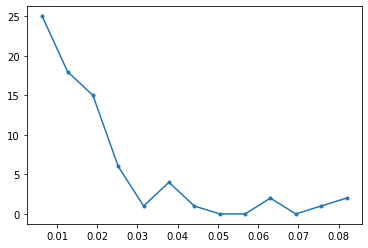

In [13]:
data = np.genfromtxt("../data/data_derived_env/max_RDS_excursions-vs-DeltaP.csv", delimiter=',', names=True)

ind = data['max_RDS_excursion'] > 0
mx_ind = np.argmax(data['DeltaP'][ind])
print(data['DeltaP'][ind][mx_ind], data['DeltaP_err'][ind][mx_ind])
hst, bin_edges = np.histogram(data['max_RDS_excursion'][ind], bins='auto')
plt.plot(bin_edges[1:], hst, marker='.')